<a href="https://colab.research.google.com/github/JoshiRawr/Deep-Learning/blob/main/CNN_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/WasteSegregation"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 26 images belonging to 4 classes.


In [ ]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4 images belonging to 4 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1538 - loss: 1.3391 - val_accuracy: 0.5000 - val_loss: 2.2930
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step - accuracy: 0.4615 - loss: 2.6851 - val_accuracy: 0.5000 - val_loss: 0.7875
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8462 - loss: 1.0318 - val_accuracy: 0.5000 - val_loss: 1.1129
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: 1.1813 - val_accuracy: 0.5000 - val_loss: 1.1920
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step - accuracy: 0.5000 - loss: 1.0458 - val_accuracy: 0.0000e+00 - val_loss: 1.1705
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step - accuracy: 0.5000 - loss: 0.8737 - val_accuracy: 0.2500 - val_loss: 1.1190
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step - accuracy: 0.6923 - loss: 0.7553 - val_accuracy: 0.5000 - val_loss: 1.1471
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step - accuracy: 0.9231 - loss: 0.6401 - val_accuracy: 0.5000 - val_loss: 1.32

In [ ]:
loss, accuracy = model.evaluate(validation_data)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5000 - loss: 1.2395
Validation Accuracy: 0.5


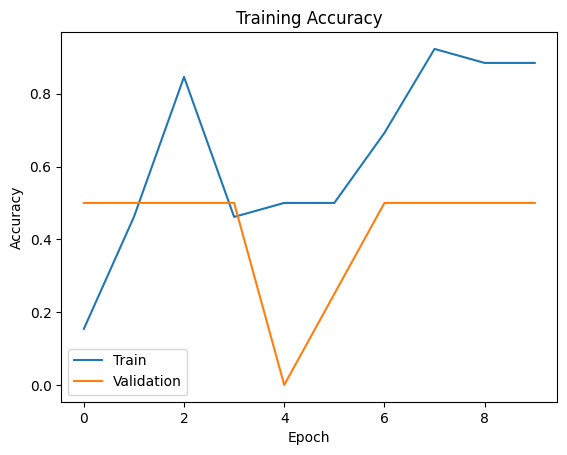

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.save("cnn_classifier.h5")